In [1]:
import pandas as pd

In [2]:
FOLD = 2

In [3]:
TARGET_C = -0.3

In [4]:
flat_windowd_df = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_{TARGET_C}_selected_genomic_windows_centered_with_steps.tsv", sep="\t")

In [5]:
chromhmm_df = pd.read_csv("/home1/smaruj/mESC_mm10_3states_H3K27ac_9ac_9me3_chromHMM.bed", sep="\t", header=None)

In [6]:
chromhmm_df.columns = [
    "chrom",        # Column 1: Chromosome
    "start",        # Column 2: Start coordinate (0-based)
    "end",          # Column 3: End coordinate (exclusive)
    "state",        # Column 4: ChromHMM state (1, 2, or 3)
    "score",        # Column 5: Score (usually 0)
    "strand",       # Column 6: Strand (usually '.')
    "thickStart",   # Column 7: For browser display
    "thickEnd",     # Column 8: For browser display
    "rgb"           # Column 9: Color code for genome browser
]

In [7]:
chromhmm_df

,chrom,start,end,state,score,strand,thickStart,thickEnd,rgb
0,chr10,7341740,7346540,1,0,.,7341740,7346540,"0,0,255"
1,chr10,7340540,7341740,2,0,.,7340540,7341740,"0,102,0"
2,chr10,7339340,7340540,1,0,.,7339340,7340540,"0,0,255"
3,chr10,7338140,7339340,2,0,.,7338140,7339340,"0,102,0"
4,chr10,7337140,7338140,1,0,.,7337140,7338140,"0,0,255"
...,...,...,...,...,...,...,...,...,...
261878,chrY,41015326,41015926,1,0,.,41015326,41015926,"0,0,255"
261879,chrY,41013926,41015326,2,0,.,41013926,41015326,"0,102,0"
261880,chrY,41013126,41013926,1,0,.,41013126,41013926,"0,0,255"
261881,chrY,40994726,41013126,2,0,.,40994726,41013126,"0,102,0"


In [8]:
state_map = {
    1: "active",
    2: "neutral",
    3: "repressive"
}
chromhmm_df["state_label"] = chromhmm_df["state"].map(state_map)

In [ ]:
# chromhmm_df

In [9]:
import bioframe as bf

In [10]:
flat_windowd_df = flat_windowd_df.rename(columns={"start": "og_start", "end": "og_end"})

In [11]:
cropping = 64
bin_size = 2048

In [12]:
flat_windowd_df["start"] = flat_windowd_df["centered_start"] + (flat_windowd_df["centered_flat_start"] + cropping) * bin_size

In [13]:
flat_windowd_df["end"] = flat_windowd_df["centered_start"] + (flat_windowd_df["centered_flat_end"] + cropping) * bin_size

In [14]:
overlap_df = bf.overlap(
    flat_windowd_df,
    chromhmm_df,
    return_index=True,
    suffixes=("_query", "_chromhmm")
)

In [15]:
result = overlap_df[[
    "chrom_query", "start_query", "end_query", "last_accepted_step_query", "state_chromhmm", "state_label_chromhmm", "centered_start_query", "centered_end_query"
]]

In [16]:
grouped = result.groupby(["chrom_query", "start_query", "end_query", "last_accepted_step_query", "centered_start_query", "centered_end_query", "state_label_chromhmm"]).size().reset_index(name="count")

In [17]:
pivoted = grouped.pivot_table(
    index=["chrom_query", "start_query", "end_query", "centered_start_query", "centered_end_query", "last_accepted_step_query"],
    columns="state_label_chromhmm",
    values="count",
    fill_value=0
).reset_index()

In [18]:
pivoted.columns.name = None
pivoted = pivoted.rename(columns={
    "active": "active_count",
    "neutral": "neutral_count",
    "repressive": "repressive_count"
})

In [19]:
pivoted["total"] = pivoted[["active_count", "neutral_count", "repressive_count"]].sum(axis=1)

In [20]:
for label in ["active", "neutral", "repressive"]:
    pivoted[f"{label}_fraction"] = pivoted[f"{label}_count"] / pivoted["total"]

In [21]:
pivoted.to_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_{TARGET_C}_chromatin_state_fractions.tsv", sep="\t", index=False)

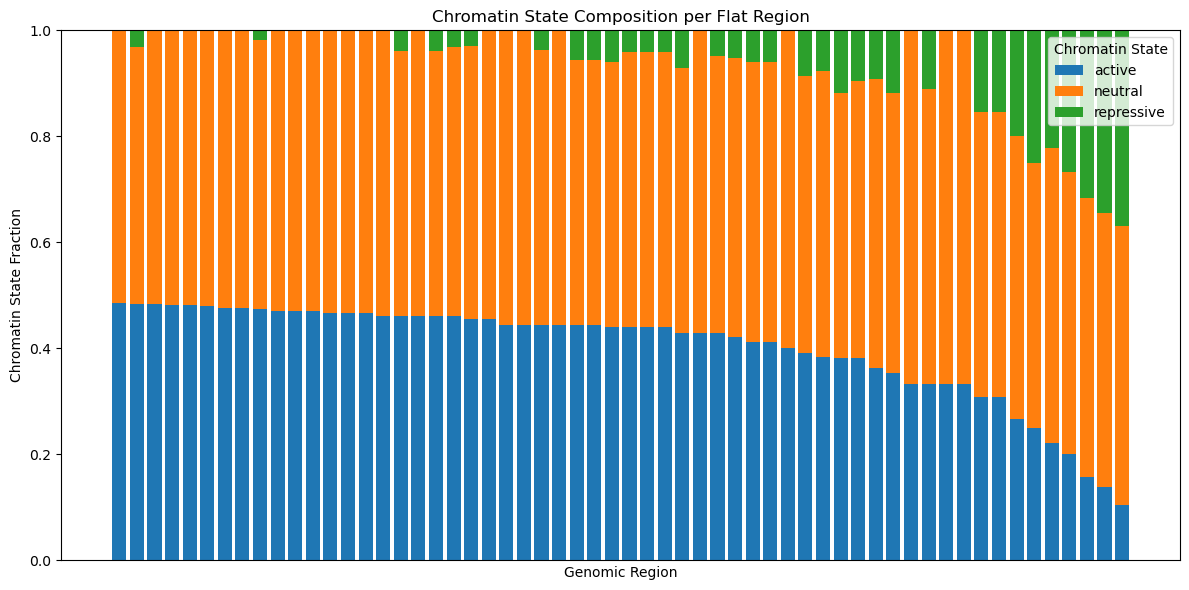

In [22]:
import matplotlib.pyplot as plt

# Sort by one of the fractions (optional)
pivoted_sorted = pivoted.sort_values("active_fraction", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bottoms = [0] * len(pivoted_sorted)

for label, color in zip(["active", "neutral", "repressive"], [None, None, None]):
    ax.bar(
        x=range(len(pivoted_sorted)),
        height=pivoted_sorted[f"{label}_fraction"],
        bottom=bottoms,
        label=label
    )
    bottoms = [sum(x) for x in zip(bottoms, pivoted_sorted[f"{label}_fraction"])]

ax.set_xlabel("Genomic Region")
ax.set_ylabel("Chromatin State Fraction")
ax.set_title("Chromatin State Composition per Flat Region")
ax.legend(title="Chromatin State")
ax.set_xticks([])  # Optional: hide x labels if not meaningful
plt.tight_layout()
plt.show()